In [59]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px



In [2]:
from google.colab import files

In [3]:
uploaded=files.upload()

Saving staging zara1.csv to staging zara1.csv


In [4]:
df=pd.read_csv('staging zara1.csv')

In [5]:
df

,Product ID,Product Position,Promotion,Seasonal,Sales Volume,sku,name,price,currency,Datetime,terms,section,Date,Total_price
0,185102,Aisle,No,No,2823,272145190-250-2,BASIC PUFFER JACKET,19.99,USD,2024-02-19T08:50:05.654618,jackets,MAN,2024-02-19,56432
1,188771,Aisle,No,No,654,324052738-800-46,TUXEDO JACKET,169.00,USD,2024-02-19T08:50:06.590930,jackets,MAN,2024-02-19,110526
2,180176,End-cap,Yes,Yes,2220,335342680-800-44,SLIM FIT SUIT JACKET,129.00,USD,2024-02-19T08:50:07.301419,jackets,MAN,2024-02-19,286380
3,112917,Aisle,Yes,Yes,1568,328303236-420-44,STRETCH SUIT JACKET,129.00,USD,2024-02-19T08:50:07.882922,jackets,MAN,2024-02-19,202272
4,192936,End-cap,No,Yes,2942,312368260-800-2,DOUBLE FACED JACKET,139.00,USD,2024-02-19T08:50:08.453847,jackets,MAN,2024-02-19,408938
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,159182,Front of Store,Yes,No,1014,321993245-500-2,FAUX LEATHER OVERSIZED JACKET LIMITED EDITION,169.00,USD,2024-02-19T09:10:43.883037,jackets,MAN,2024-02-19,171366
248,199233,Aisle,Yes,No,2222,330590505-500-2,CONTRASTING PATCHES BOMBER JACKET,159.00,USD,2024-02-19T09:10:44.463883,jackets,MAN,2024-02-19,353298
249,137044,Aisle,No,Yes,2534,320680326-107-39,PATCH BOMBER JACKET,12.99,USD,2024-02-19T09:10:45.009106,jackets,MAN,2024-02-19,32917
250,154736,Front of Store,Yes,Yes,1466,311292244-800-39,CROPPED BOMBER JACKET LIMITED EDITION,19.90,USD,2024-02-19T09:10:45.631804,jackets,MAN,2024-02-19,29173


## Data Cleaning


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product ID        252 non-null    int64  
 1   Product Position  252 non-null    object 
 2   Promotion         252 non-null    object 
 3   Seasonal          252 non-null    object 
 4   Sales Volume      252 non-null    int64  
 5   sku               252 non-null    object 
 6   name              251 non-null    object 
 7   price             252 non-null    float64
 8   currency          252 non-null    object 
 9   Datetime          252 non-null    object 
 10  terms             252 non-null    object 
 11  section           252 non-null    object 
 12  Date              252 non-null    object 
 13  Total_price       252 non-null    int64  
dtypes: float64(1), int64(3), object(10)
memory usage: 27.7+ KB


In [7]:
df.head()

,Product ID,Product Position,Promotion,Seasonal,Sales Volume,sku,name,price,currency,Datetime,terms,section,Date,Total_price
0,185102,Aisle,No,No,2823,272145190-250-2,BASIC PUFFER JACKET,19.99,USD,2024-02-19T08:50:05.654618,jackets,MAN,2024-02-19,56432
1,188771,Aisle,No,No,654,324052738-800-46,TUXEDO JACKET,169.00,USD,2024-02-19T08:50:06.590930,jackets,MAN,2024-02-19,110526
2,180176,End-cap,Yes,Yes,2220,335342680-800-44,SLIM FIT SUIT JACKET,129.00,USD,2024-02-19T08:50:07.301419,jackets,MAN,2024-02-19,286380
3,112917,Aisle,Yes,Yes,1568,328303236-420-44,STRETCH SUIT JACKET,129.00,USD,2024-02-19T08:50:07.882922,jackets,MAN,2024-02-19,202272
4,192936,End-cap,No,Yes,2942,312368260-800-2,DOUBLE FACED JACKET,139.00,USD,2024-02-19T08:50:08.453847,jackets,MAN,2024-02-19,408938


In [8]:
df.tail()

,Product ID,Product Position,Promotion,Seasonal,Sales Volume,sku,name,price,currency,Datetime,terms,section,Date,Total_price
247,159182,Front of Store,Yes,No,1014,321993245-500-2,FAUX LEATHER OVERSIZED JACKET LIMITED EDITION,169.00,USD,2024-02-19T09:10:43.883037,jackets,MAN,2024-02-19,171366
248,199233,Aisle,Yes,No,2222,330590505-500-2,CONTRASTING PATCHES BOMBER JACKET,159.00,USD,2024-02-19T09:10:44.463883,jackets,MAN,2024-02-19,353298
249,137044,Aisle,No,Yes,2534,320680326-107-39,PATCH BOMBER JACKET,12.99,USD,2024-02-19T09:10:45.009106,jackets,MAN,2024-02-19,32917
250,154736,Front of Store,Yes,Yes,1466,311292244-800-39,CROPPED BOMBER JACKET LIMITED EDITION,19.90,USD,2024-02-19T09:10:45.631804,jackets,MAN,2024-02-19,29173
251,141434,Front of Store,No,Yes,2870,311307610-400-39,FAUX LEATHER PUFFER JACKET,39.90,USD,2024-02-19T09:10:31.877972,jackets,MAN,2024-02-19,114513


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['Date']=pd.to_datetime(df['Date'])
df['Datetime']=pd.to_datetime(df['Datetime'])

In [11]:
df['time']=df['Datetime'].dt.time
df['Datetime'].dt.hour
df

,Product ID,Product Position,Promotion,Seasonal,Sales Volume,sku,name,price,currency,Datetime,terms,section,Date,Total_price,time
0,185102,Aisle,No,No,2823,272145190-250-2,BASIC PUFFER JACKET,19.99,USD,2024-02-19 08:50:05.654618,jackets,MAN,2024-02-19,56432,08:50:05.654618
1,188771,Aisle,No,No,654,324052738-800-46,TUXEDO JACKET,169.00,USD,2024-02-19 08:50:06.590930,jackets,MAN,2024-02-19,110526,08:50:06.590930
2,180176,End-cap,Yes,Yes,2220,335342680-800-44,SLIM FIT SUIT JACKET,129.00,USD,2024-02-19 08:50:07.301419,jackets,MAN,2024-02-19,286380,08:50:07.301419
3,112917,Aisle,Yes,Yes,1568,328303236-420-44,STRETCH SUIT JACKET,129.00,USD,2024-02-19 08:50:07.882922,jackets,MAN,2024-02-19,202272,08:50:07.882922
4,192936,End-cap,No,Yes,2942,312368260-800-2,DOUBLE FACED JACKET,139.00,USD,2024-02-19 08:50:08.453847,jackets,MAN,2024-02-19,408938,08:50:08.453847
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,159182,Front of Store,Yes,No,1014,321993245-500-2,FAUX LEATHER OVERSIZED JACKET LIMITED EDITION,169.00,USD,2024-02-19 09:10:43.883037,jackets,MAN,2024-02-19,171366,09:10:43.883037
248,199233,Aisle,Yes,No,2222,330590505-500-2,CONTRASTING PATCHES BOMBER JACKET,159.00,USD,2024-02-19 09:10:44.463883,jackets,MAN,2024-02-19,353298,09:10:44.463883
249,137044,Aisle,No,Yes,2534,320680326-107-39,PATCH BOMBER JACKET,12.99,USD,2024-02-19 09:10:45.009106,jackets,MAN,2024-02-19,32917,09:10:45.009106
250,154736,Front of Store,Yes,Yes,1466,311292244-800-39,CROPPED BOMBER JACKET LIMITED EDITION,19.90,USD,2024-02-19 09:10:45.631804,jackets,MAN,2024-02-19,29173,09:10:45.631804


In [12]:
t_month={1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
         7:'July',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

In [13]:
df['Month']=df['Month'].map(t_month)

KeyError: 'Month'

## EDA EXPLORATORY

In [14]:
df.describe()

,Product ID,Sales Volume,price,Datetime,Date,Total_price
count,252.000000,252.000000,252.000000,252,252,252.000000
mean,153370.503968,1823.702381,86.252540,2024-02-19 08:57:11.426206464,2024-02-19 00:00:00,154716.182540
min,110075.000000,529.000000,7.990000,2024-02-19 08:50:05.654618,2024-02-19 00:00:00,4331.000000
25%,131053.750000,1243.000000,49.900000,2024-02-19 08:50:45.615702272,2024-02-19 00:00:00,77599.000000
50%,151681.500000,1839.500000,79.900000,2024-02-19 08:51:39.882414592,2024-02-19 00:00:00,129888.000000
75%,175669.750000,2398.750000,109.000000,2024-02-19 09:00:47.821253632,2024-02-19 00:00:00,199768.500000
max,199631.000000,2989.000000,439.000000,2024-02-19 09:10:52.485772,2024-02-19 00:00:00,651521.000000
std,26160.444549,697.703748,52.083205,NaN,NaN,107025.243803


In [15]:
df.head()

,Product ID,Product Position,Promotion,Seasonal,Sales Volume,sku,name,price,currency,Datetime,terms,section,Date,Total_price,time
0,185102,Aisle,No,No,2823,272145190-250-2,BASIC PUFFER JACKET,19.99,USD,2024-02-19 08:50:05.654618,jackets,MAN,2024-02-19,56432,08:50:05.654618
1,188771,Aisle,No,No,654,324052738-800-46,TUXEDO JACKET,169.00,USD,2024-02-19 08:50:06.590930,jackets,MAN,2024-02-19,110526,08:50:06.590930
2,180176,End-cap,Yes,Yes,2220,335342680-800-44,SLIM FIT SUIT JACKET,129.00,USD,2024-02-19 08:50:07.301419,jackets,MAN,2024-02-19,286380,08:50:07.301419
3,112917,Aisle,Yes,Yes,1568,328303236-420-44,STRETCH SUIT JACKET,129.00,USD,2024-02-19 08:50:07.882922,jackets,MAN,2024-02-19,202272,08:50:07.882922
4,192936,End-cap,No,Yes,2942,312368260-800-2,DOUBLE FACED JACKET,139.00,USD,2024-02-19 08:50:08.453847,jackets,MAN,2024-02-19,408938,08:50:08.453847


In [16]:
px.histogram(df, x='terms',y='Sales Volume',color='Promotion',marginal='box',title='Product volumes sales relative to promotion')

In [17]:
volume_sale_pr=df[['terms','Promotion','Sales Volume']].groupby(['terms','Promotion']).sum()/df[['Sales Volume','terms']].groupby('terms').sum()*100

In [18]:
volume_sale_pr

Sales Volume
terms    Promotion              
jackets  No            51.804461
         Yes           48.195539
jeans    No            64.647147
         Yes           35.352853
shoes    No            49.321314
         Yes           50.678686
sweaters No            51.116398
         Yes           48.883602
t-shirts No            56.423737
         Yes           43.576263

### sales volume  relative to promotion

* 48.19% of the jackets were in promtion
* 35.35% of the jeans were in promotion
* 50.67% of the shoes were in promotion
* 48.88% of the sweaters were in promotion
* 43.57% of the t-shirts were in promotion

In [19]:
px.histogram(df, x='terms',y='Total_price',color='Promotion',title="Revenue generated by product relative to promotion" ,marginal="box")




In [20]:
revenue_sale_pr=df[['terms','Promotion','Total_price']].groupby(['terms','Promotion']).sum()/df[['Total_price','terms']].groupby('terms').sum()*100
promotion_impact=revenue_sale_pr.merge(volume_sale_pr,on=['terms','Promotion'],how='inner')

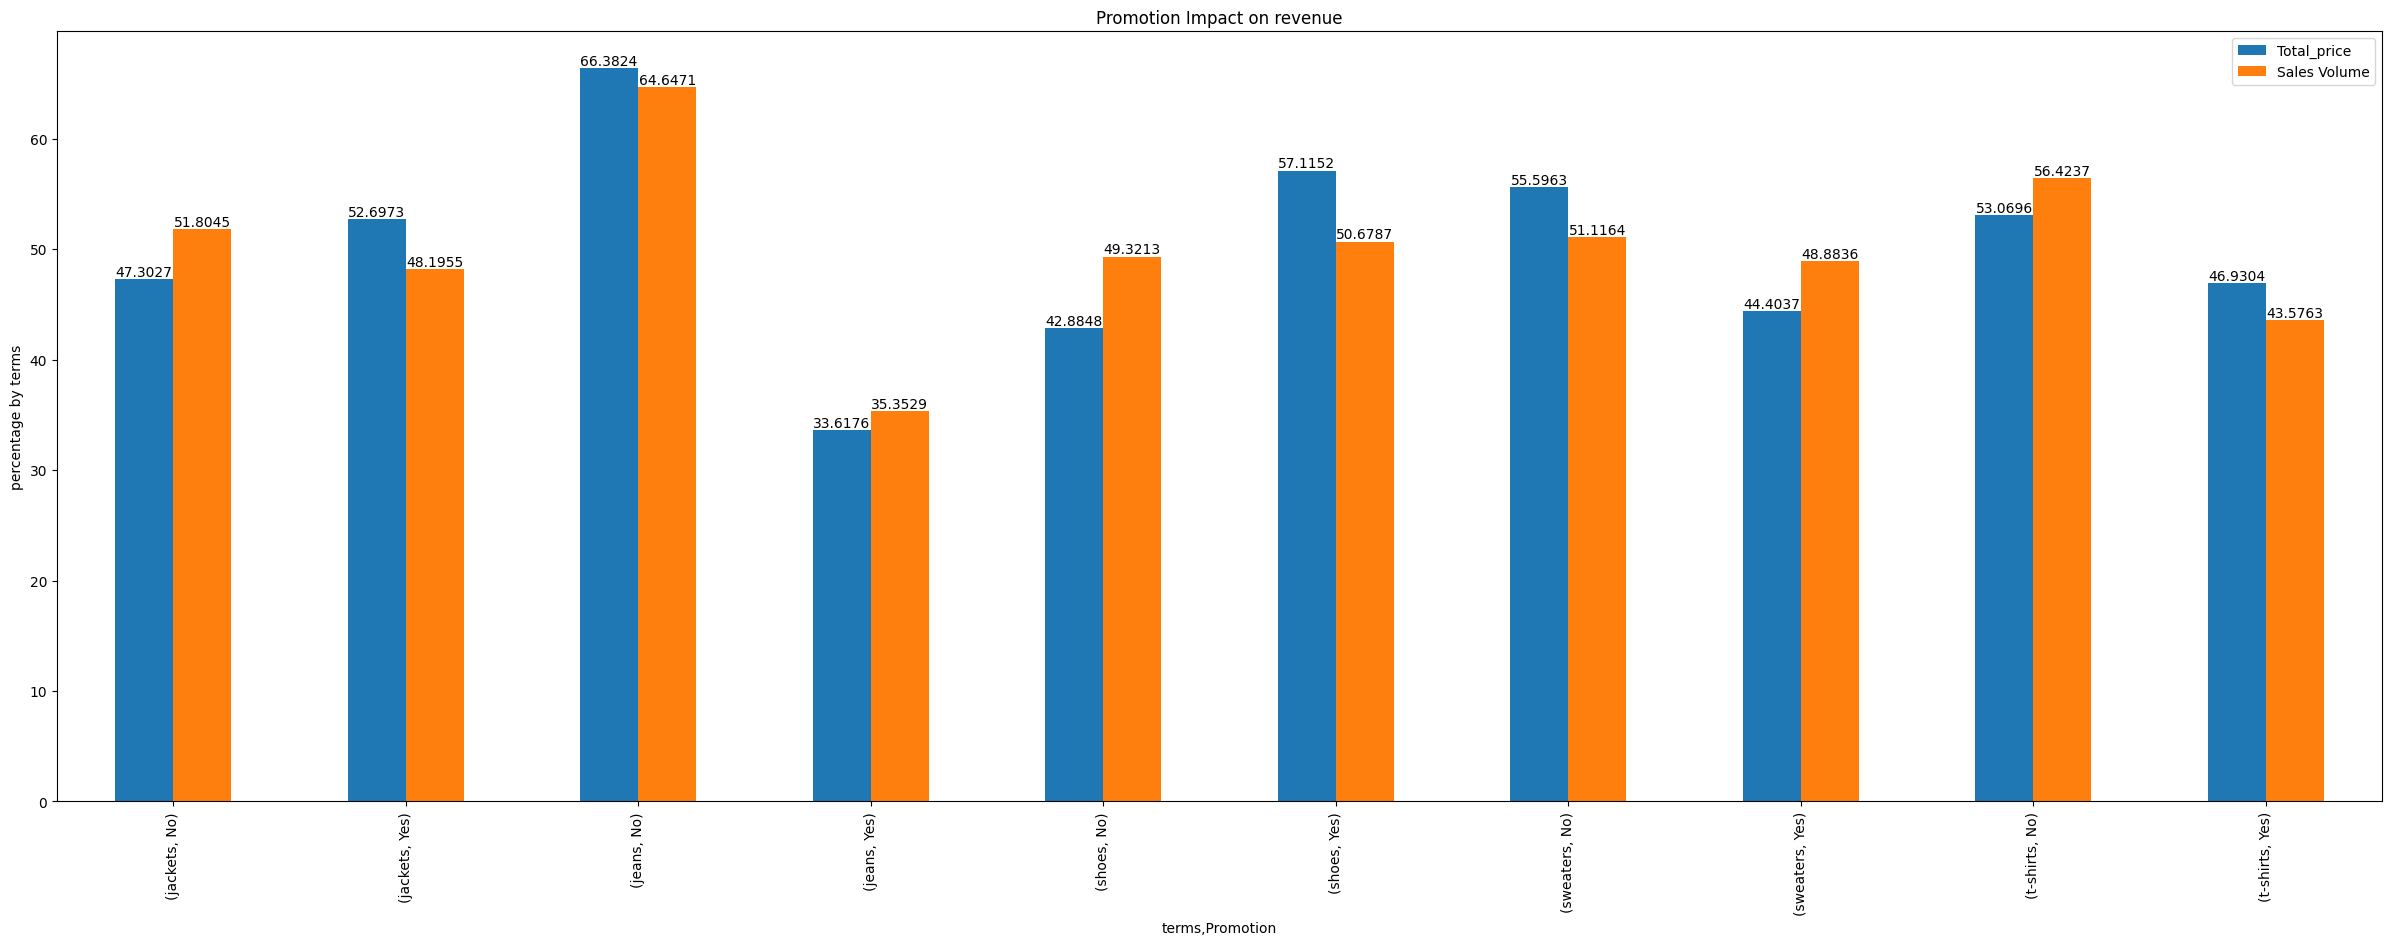

In [21]:
ax=promotion_impact.plot.bar(ylabel='percentage by terms',title='Promotion Impact on revenue',figsize=(30,10))
for container in ax.containers:
  ax.bar_label(container)


In [22]:
promotion_impact['ratio']=promotion_impact['Total_price']/promotion_impact['Sales Volume']

In [23]:
promotion_impact

Total_price  Sales Volume     ratio
terms    Promotion                                     
jackets  No           47.302690     51.804461  0.913101
         Yes          52.697310     48.195539  1.093406
jeans    No           66.382380     64.647147  1.026842
         Yes          33.617620     35.352853  0.950917
shoes    No           42.884791     49.321314  0.869498
         Yes          57.115209     50.678686  1.127007
sweaters No           55.596348     51.116398  1.087642
         Yes          44.403652     48.883602  0.908355
t-shirts No           53.069554     56.423737  0.940554
         Yes          46.930446     43.576263  1.076973

In [24]:
promotion_ratio=promotion_impact.drop(columns={'Total_price','Sales Volume'})
promotion_ratio.reset_index(inplace=True)

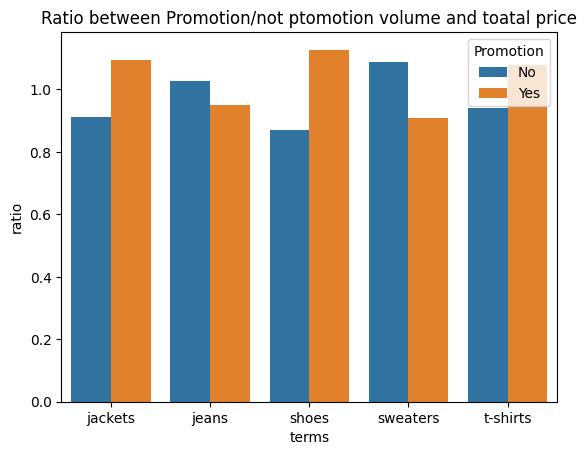

In [25]:
sns.barplot(promotion_ratio,x='terms',y='ratio',hue='Promotion')
plt.title('Ratio between Promotion/not ptomotion volume and toatal price')
plt.show()

## Promotion impact on revenue

* for jackets,shoes and t-shirts were  increasing their revenue
* for jeans and sweaters promotion were decreasing their revenue

In [26]:
px.histogram(df, x='terms',y='Sales Volume',color='Seasonal',marginal='box',title='Product volumes sales relative to promotion')

In [27]:
px.histogram(df, x='terms',y='Total_price',color='Seasonal',title="Revenue generated by product relative to seasonal" ,marginal="box")




In [28]:
volume_sale_se=df[['terms','Seasonal','Sales Volume']].groupby(['terms','Seasonal']).sum()/df[['Sales Volume','terms']].groupby('terms').sum()*100
revenue_sale_pr=df[['terms','Seasonal','Total_price']].groupby(['terms','Seasonal']).sum()/df[['Total_price','terms']].groupby('terms').sum()*100
seasonal_impact=revenue_sale_pr.merge(volume_sale_se,on=['terms','Seasonal'],how='inner')
seasonal_impact

Total_price  Sales Volume
terms    Seasonal                           
jackets  No          47.927907     47.846748
         Yes         52.072093     52.153252
jeans    No          65.312256     72.612613
         Yes         34.687744     27.387387
shoes    No          69.630426     68.737264
         Yes         30.369574     31.262736
sweaters No          27.027560     26.939741
         Yes         72.972440     73.060259
t-shirts No          57.661192     60.592501
         Yes         42.338808     39.407499

In [29]:
seasonal_impact['ratio']=seasonal_impact['Total_price']/seasonal_impact['Sales Volume']
seasonal_ratio=seasonal_impact.drop(columns={'Total_price','Sales Volume'})
seasonal_ratio.reset_index(inplace=True)

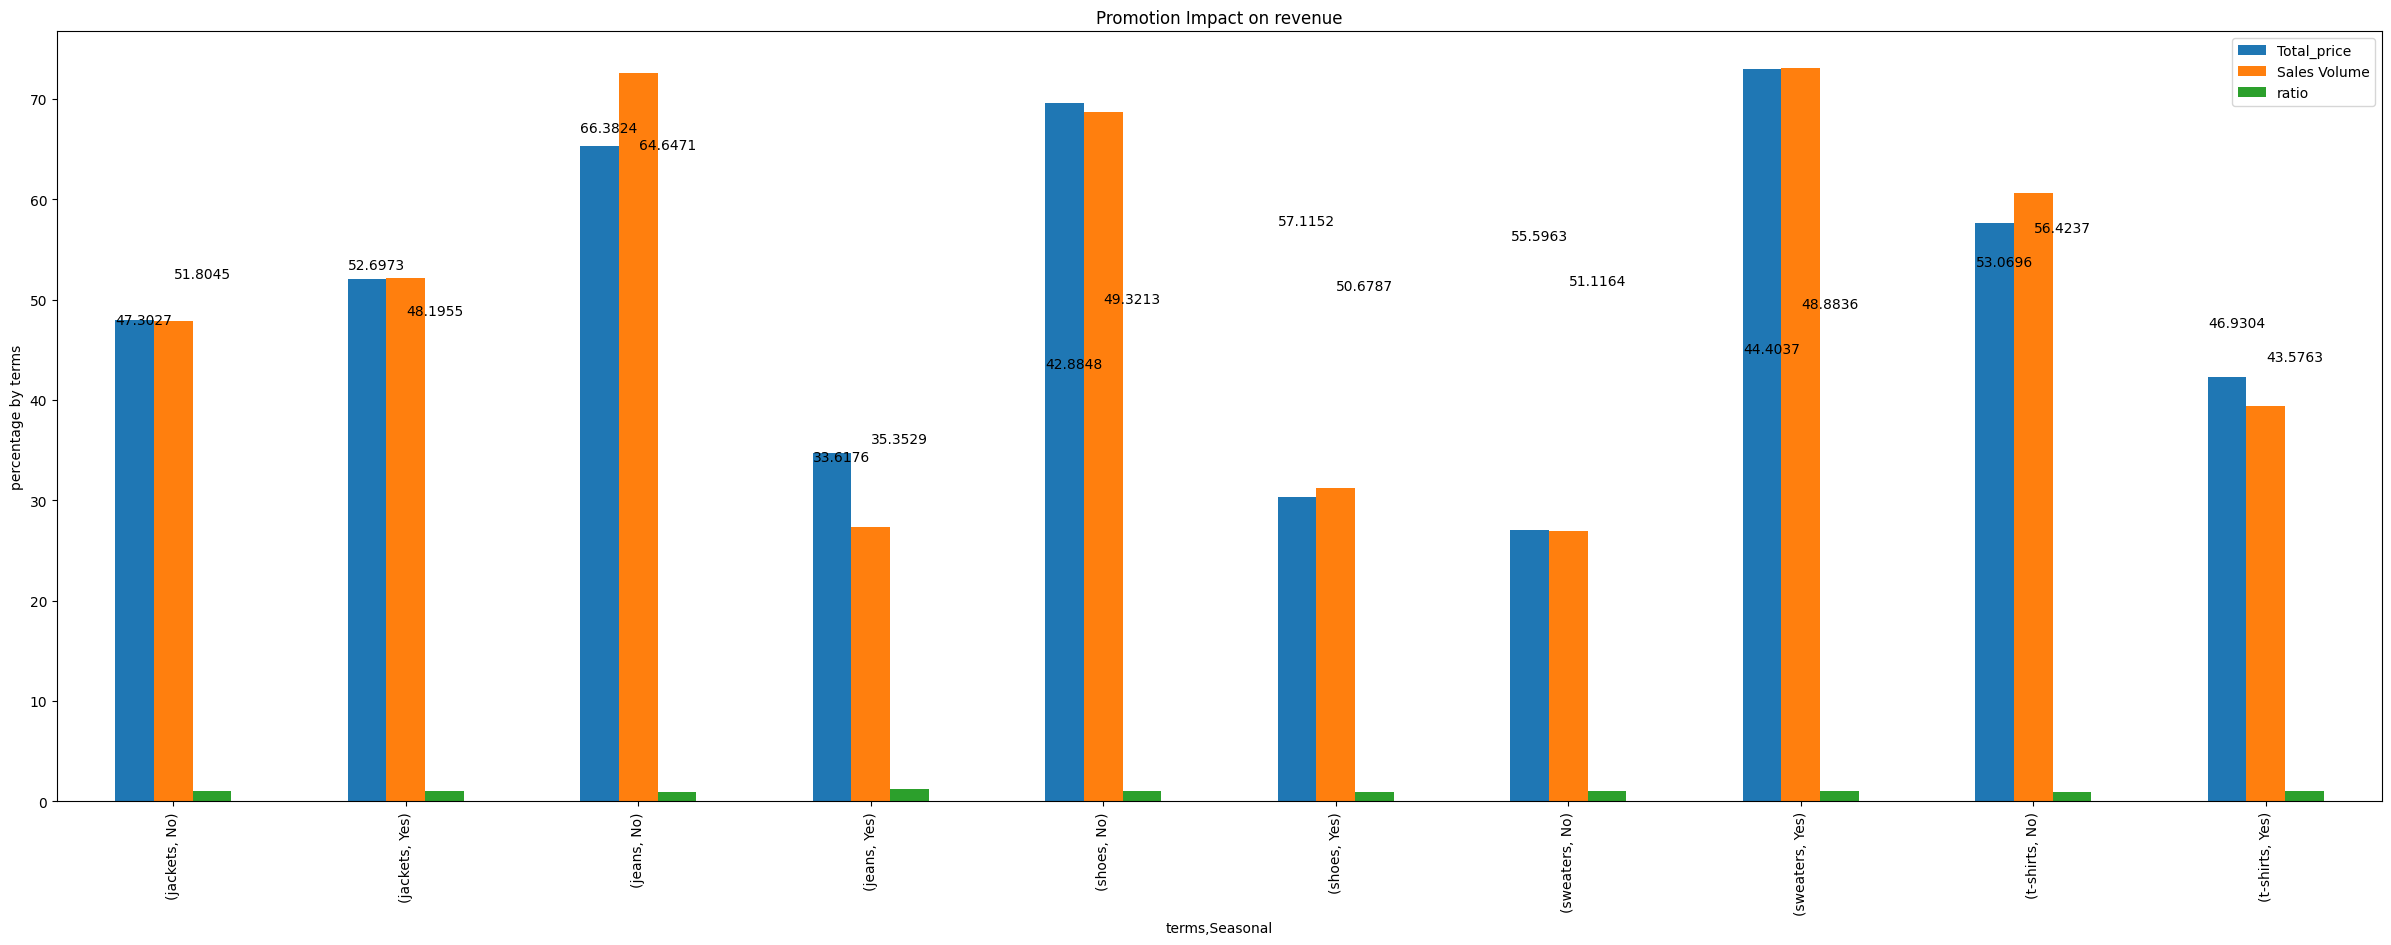

In [30]:
ax1=seasonal_impact.plot.bar(ylabel='percentage by terms',title='Promotion Impact on revenue',figsize=(30,10))
for container in ax.containers:
  ax1.bar_label(container)


In [31]:
seasonal_impact

Total_price  Sales Volume     ratio
terms    Seasonal                                     
jackets  No          47.927907     47.846748  1.001696
         Yes         52.072093     52.153252  0.998444
jeans    No          65.312256     72.612613  0.899462
         Yes         34.687744     27.387387  1.266559
shoes    No          69.630426     68.737264  1.012994
         Yes         30.369574     31.262736  0.971430
sweaters No          27.027560     26.939741  1.003260
         Yes         72.972440     73.060259  0.998798
t-shirts No          57.661192     60.592501  0.951623
         Yes         42.338808     39.407499  1.074385

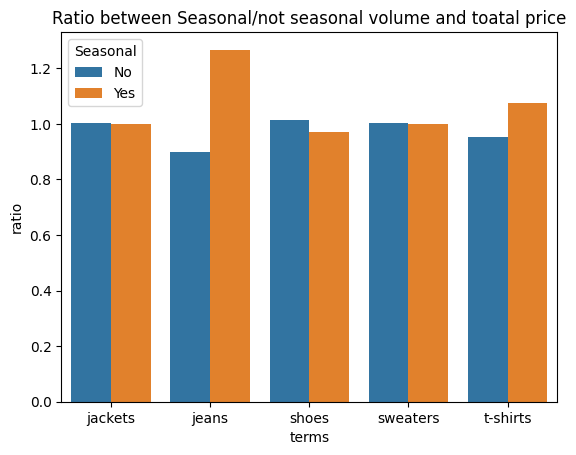

In [32]:
sns.barplot(seasonal_ratio,x='terms',y='ratio',hue='Seasonal')
plt.title('Ratio between Seasonal/not seasonal volume and toatal price')
plt.show()

# seasonal impact on revenue
* jackets and sweaters the seasonal didn't have a real impact on their revenue
* shoes and t-shirt the seasonal had a light impact on the revenue

* jeasn the seasonal had an impacy on the revenue

In [33]:
df

,Product ID,Product Position,Promotion,Seasonal,Sales Volume,sku,name,price,currency,Datetime,terms,section,Date,Total_price,time
0,185102,Aisle,No,No,2823,272145190-250-2,BASIC PUFFER JACKET,19.99,USD,2024-02-19 08:50:05.654618,jackets,MAN,2024-02-19,56432,08:50:05.654618
1,188771,Aisle,No,No,654,324052738-800-46,TUXEDO JACKET,169.00,USD,2024-02-19 08:50:06.590930,jackets,MAN,2024-02-19,110526,08:50:06.590930
2,180176,End-cap,Yes,Yes,2220,335342680-800-44,SLIM FIT SUIT JACKET,129.00,USD,2024-02-19 08:50:07.301419,jackets,MAN,2024-02-19,286380,08:50:07.301419
3,112917,Aisle,Yes,Yes,1568,328303236-420-44,STRETCH SUIT JACKET,129.00,USD,2024-02-19 08:50:07.882922,jackets,MAN,2024-02-19,202272,08:50:07.882922
4,192936,End-cap,No,Yes,2942,312368260-800-2,DOUBLE FACED JACKET,139.00,USD,2024-02-19 08:50:08.453847,jackets,MAN,2024-02-19,408938,08:50:08.453847
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,159182,Front of Store,Yes,No,1014,321993245-500-2,FAUX LEATHER OVERSIZED JACKET LIMITED EDITION,169.00,USD,2024-02-19 09:10:43.883037,jackets,MAN,2024-02-19,171366,09:10:43.883037
248,199233,Aisle,Yes,No,2222,330590505-500-2,CONTRASTING PATCHES BOMBER JACKET,159.00,USD,2024-02-19 09:10:44.463883,jackets,MAN,2024-02-19,353298,09:10:44.463883
249,137044,Aisle,No,Yes,2534,320680326-107-39,PATCH BOMBER JACKET,12.99,USD,2024-02-19 09:10:45.009106,jackets,MAN,2024-02-19,32917,09:10:45.009106
250,154736,Front of Store,Yes,Yes,1466,311292244-800-39,CROPPED BOMBER JACKET LIMITED EDITION,19.90,USD,2024-02-19 09:10:45.631804,jackets,MAN,2024-02-19,29173,09:10:45.631804


In [34]:
Total_sku=df['sku'].nunique()
Total_sku

228

* Total sku was 228

In [35]:
df['Product Position'].nunique()

3

In [36]:
px.histogram(df, x='terms',y='Total_price',color='Product Position',title="Revenue generated by product relative to position" ,marginal="box")




In [37]:
volume_sale_ps=df[['terms','Product Position','Sales Volume']].groupby(['terms','Product Position']).sum()/df[['Sales Volume','terms']].groupby('terms').sum()*100
revenue_sale_ps=df[['terms','Product Position','Total_price']].groupby(['terms','Product Position']).sum()/df[['Total_price','terms']].groupby('terms').sum()*100
position_impact=revenue_sale_ps.merge(volume_sale_ps,on=['terms','Product Position'],how='inner')
position_impact

Total_price  Sales Volume
terms    Product Position                           
jackets  Aisle               40.799895     39.533584
         End-cap             30.025025     29.947816
         Front of Store      29.175080     30.518600
jeans    Aisle               26.096790     34.527027
         End-cap             38.564137     38.821321
         Front of Store      35.339073     26.651652
shoes    Aisle               37.610234     42.157980
         End-cap             33.208605     30.922530
         Front of Store      29.181160     26.919490
sweaters Aisle               29.674070     26.610138
         End-cap             41.183416     43.478376
         Front of Store      29.142514     29.911486
t-shirts Aisle               48.270007     48.075023
         End-cap             35.174517     36.232451
         Front of Store      16.555476     15.692526

In [38]:
position_impact['ratio']=position_impact['Total_price']/position_impact['Sales Volume']
position_ratio=position_impact.drop(columns={'Total_price','Sales Volume'})
position_ratio.reset_index(inplace=True)

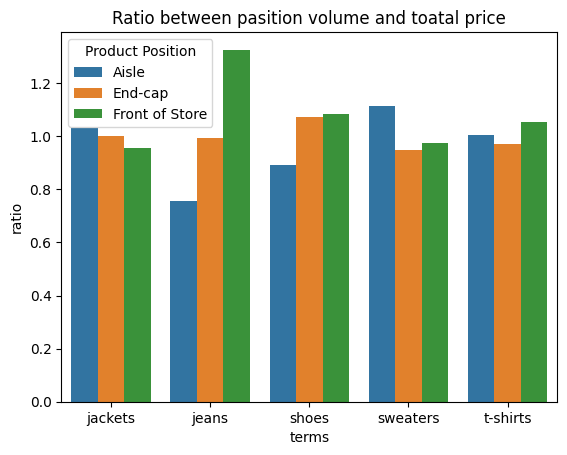

In [39]:
sns.barplot(position_ratio,x='terms',y='ratio',hue='Product Position')
plt.title('Ratio between pasition volume and toatal price')
plt.rcParams['figure.figsize']=(30,10)
plt.show()


## Keys insight
### sales volume  relative to promotion

* 48.19% of the jackets were in promtion
* 35.35% of the jeans were in promotion
* 50.67% of the shoes were in promotion
* 48.88% of the sweaters were in promotion
* 43.57% of the t-shirts were in promotion

### Promotion impact on revenue

* for jackets,shoes and t-shirts were  increasing their revenue
* for jeans and sweaters promotion were decreasing their revenue

### seasonal impact on revenue
* jackets and sweaters the seasonal didn't have a real impact on their revenue
* shoes and t-shirt the seasonal had a light impact on the revenue

* jeasn the seasonal had an impacy on the revenue

In [40]:
df

,Product ID,Product Position,Promotion,Seasonal,Sales Volume,sku,name,price,currency,Datetime,terms,section,Date,Total_price,time
0,185102,Aisle,No,No,2823,272145190-250-2,BASIC PUFFER JACKET,19.99,USD,2024-02-19 08:50:05.654618,jackets,MAN,2024-02-19,56432,08:50:05.654618
1,188771,Aisle,No,No,654,324052738-800-46,TUXEDO JACKET,169.00,USD,2024-02-19 08:50:06.590930,jackets,MAN,2024-02-19,110526,08:50:06.590930
2,180176,End-cap,Yes,Yes,2220,335342680-800-44,SLIM FIT SUIT JACKET,129.00,USD,2024-02-19 08:50:07.301419,jackets,MAN,2024-02-19,286380,08:50:07.301419
3,112917,Aisle,Yes,Yes,1568,328303236-420-44,STRETCH SUIT JACKET,129.00,USD,2024-02-19 08:50:07.882922,jackets,MAN,2024-02-19,202272,08:50:07.882922
4,192936,End-cap,No,Yes,2942,312368260-800-2,DOUBLE FACED JACKET,139.00,USD,2024-02-19 08:50:08.453847,jackets,MAN,2024-02-19,408938,08:50:08.453847
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,159182,Front of Store,Yes,No,1014,321993245-500-2,FAUX LEATHER OVERSIZED JACKET LIMITED EDITION,169.00,USD,2024-02-19 09:10:43.883037,jackets,MAN,2024-02-19,171366,09:10:43.883037
248,199233,Aisle,Yes,No,2222,330590505-500-2,CONTRASTING PATCHES BOMBER JACKET,159.00,USD,2024-02-19 09:10:44.463883,jackets,MAN,2024-02-19,353298,09:10:44.463883
249,137044,Aisle,No,Yes,2534,320680326-107-39,PATCH BOMBER JACKET,12.99,USD,2024-02-19 09:10:45.009106,jackets,MAN,2024-02-19,32917,09:10:45.009106
250,154736,Front of Store,Yes,Yes,1466,311292244-800-39,CROPPED BOMBER JACKET LIMITED EDITION,19.90,USD,2024-02-19 09:10:45.631804,jackets,MAN,2024-02-19,29173,09:10:45.631804


In [41]:
df.corr(numeric_only=True)

,Product ID,Sales Volume,price,Total_price
Product ID,1.000000,-0.120419,-0.073822,-0.149008
Sales Volume,-0.120419,1.000000,-0.071359,0.500058
price,-0.073822,-0.071359,1.000000,0.753908
Total_price,-0.149008,0.500058,0.753908,1.000000


# Data processing

In [42]:
from sklearn.model_selection import train_test_split

In [439]:
train_df,r_df=train_test_split(df,train_size=0.5,random_state=42)
val_df,test_df=train_test_split(r_df,train_size=0.5,random_state=42)

In [440]:
print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(126, 15)
(63, 15)
(63, 15)


In [441]:
inputs=['Product Position', 'Promotion', 'Seasonal',
       'Sales Volume']
targets='price'

In [442]:
train_inputs=train_df[inputs].copy()
val_inputs=val_df[inputs].copy()
test_inputs=test_df[inputs].copy()
train_targets=train_df[targets].copy()
val_targets=val_df[targets].copy()
test_targets=test_df[targets].copy()

In [443]:
numeric_cols=train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_col=train_inputs.select_dtypes('object').columns.tolist()

In [444]:
from sklearn.impute import SimpleImputer

In [445]:
imputer=SimpleImputer(strategy='mean').fit(df[numeric_cols])
train_inputs[numeric_cols]=imputer.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols]=imputer.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols]=imputer.transform(test_inputs[numeric_cols])


In [446]:
from sklearn.preprocessing import StandardScaler

In [447]:
Sscaler=StandardScaler().fit(train_inputs[numeric_cols])
train_inputs[numeric_cols]=scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols]=scaler.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols]=scaler.transform(test_inputs[numeric_cols])

In [448]:
from sklearn.preprocessing import OneHotEncoder
import warnings
warnings.filterwarnings('ignore')

In [449]:
encoder=OneHotEncoder(handle_unknown='ignore',sparse_output=False).fit(train_inputs[categorical_col])
encoded_col=list(encoder.get_feature_names_out((categorical_col)))
train_inputs[encoded_col]=encoder.transform(train_inputs[categorical_col])
val_inputs[encoded_col]=encoder.transform(val_inputs[categorical_col])
test_inputs[encoded_col]=encoder.transform(test_inputs[categorical_col])

In [450]:
X_train=train_inputs[encoded_col + numeric_cols]
X_val=val_inputs[encoded_col + numeric_cols]
X_test=test_inputs[encoded_col + numeric_cols]

In [451]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error,mean_absolute_error

In [452]:
model1=LinearRegression().fit(X_train,train_targets)
preds_train=model1.predict(X_train)
root_mean_squared_error(train_targets,preds_train)

50.922517002855635

In [453]:
preds_val=model1.predict(X_val)
root_mean_squared_error(val_targets,preds_val)

57.18816885203087

In [454]:
preds_test=model1.predict(X_test)
root_mean_squared_error(test_targets,preds_test)

47.98973190777141

In [455]:
from sklearn.tree import DecisionTreeRegressor

In [456]:
from sklearn.model_selection import GridSearchCV

In [457]:
parmas1={
    'max_depth':[2,3,5,6,8],
    'random_state':[42]
}

In [458]:
model2=DecisionTreeRegressor()

In [459]:
grid=GridSearchCV(model2,parmas1)
grid.fit(X_train,train_targets)

GridSearchCV(estimator=DecisionTreeRegressor(),
             param_grid={'max_depth': [2, 3, 5, 6, 8], 'random_state': [42]})

In [460]:
grid.best_estimator_

DecisionTreeRegressor(max_depth=2, random_state=42)

In [461]:
bestmodel=grid.best_estimator_
preds_traint=bestmodel.predict(X_train)
root_mean_squared_error(preds_traint,train_targets)

47.384188681100795

In [462]:
preds_valt=bestmodel.predict(X_val)
root_mean_squared_error(preds_valt,val_targets)

59.45789112627737

In [463]:
preds_testt=bestmodel.predict(X_test)
root_mean_squared_error(preds_testt,test_targets)

51.24404574264256

In [464]:
from sklearn.tree import plot_tree

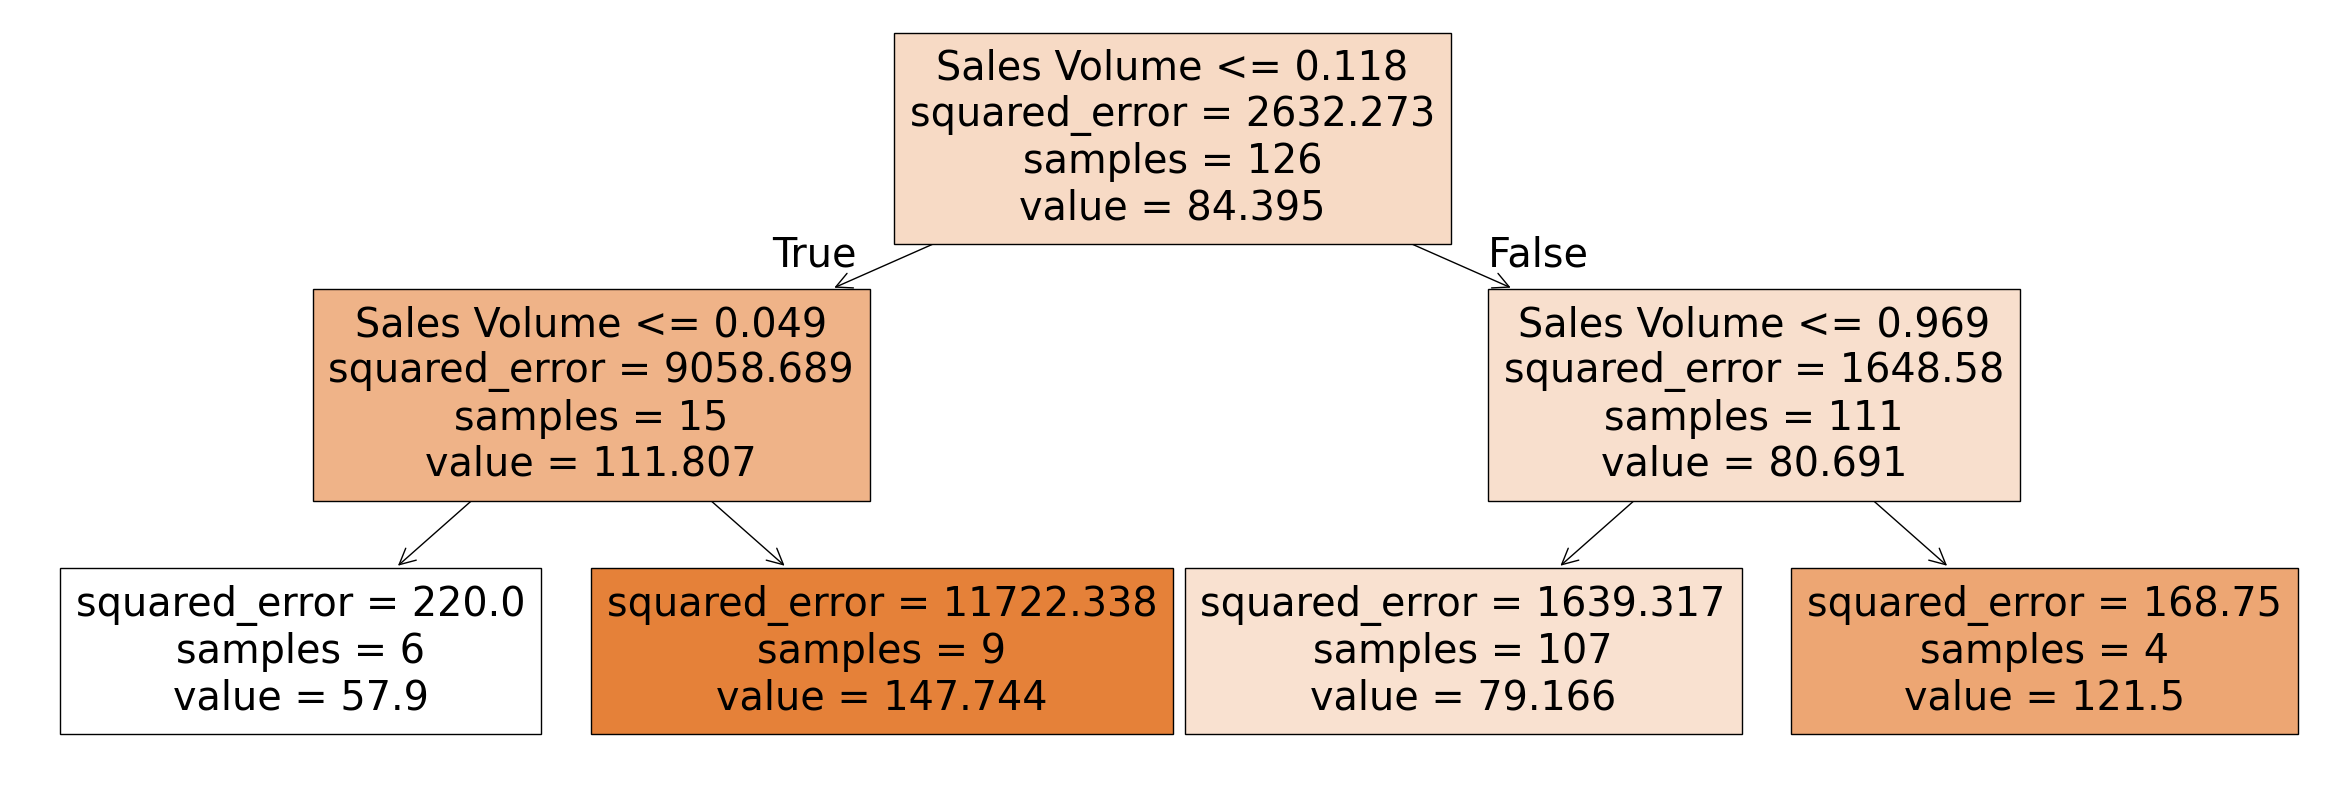

In [465]:
plot_tree(bestmodel,feature_names=X_train.columns,filled=True)
plt.show()

In [466]:
importance=pd.DataFrame({
   'feature':X_train.columns,
   'importances':bestmodel.feature_importances_
}

).sort_values('importances',ascending=False)

In [467]:
importance.head(10)

,feature,importances
7,Sales Volume,1.0
0,Product Position_Aisle,0.0
2,Product Position_Front of Store,0.0
1,Product Position_End-cap,0.0
3,Promotion_No,0.0
4,Promotion_Yes,0.0
5,Seasonal_No,0.0
6,Seasonal_Yes,0.0


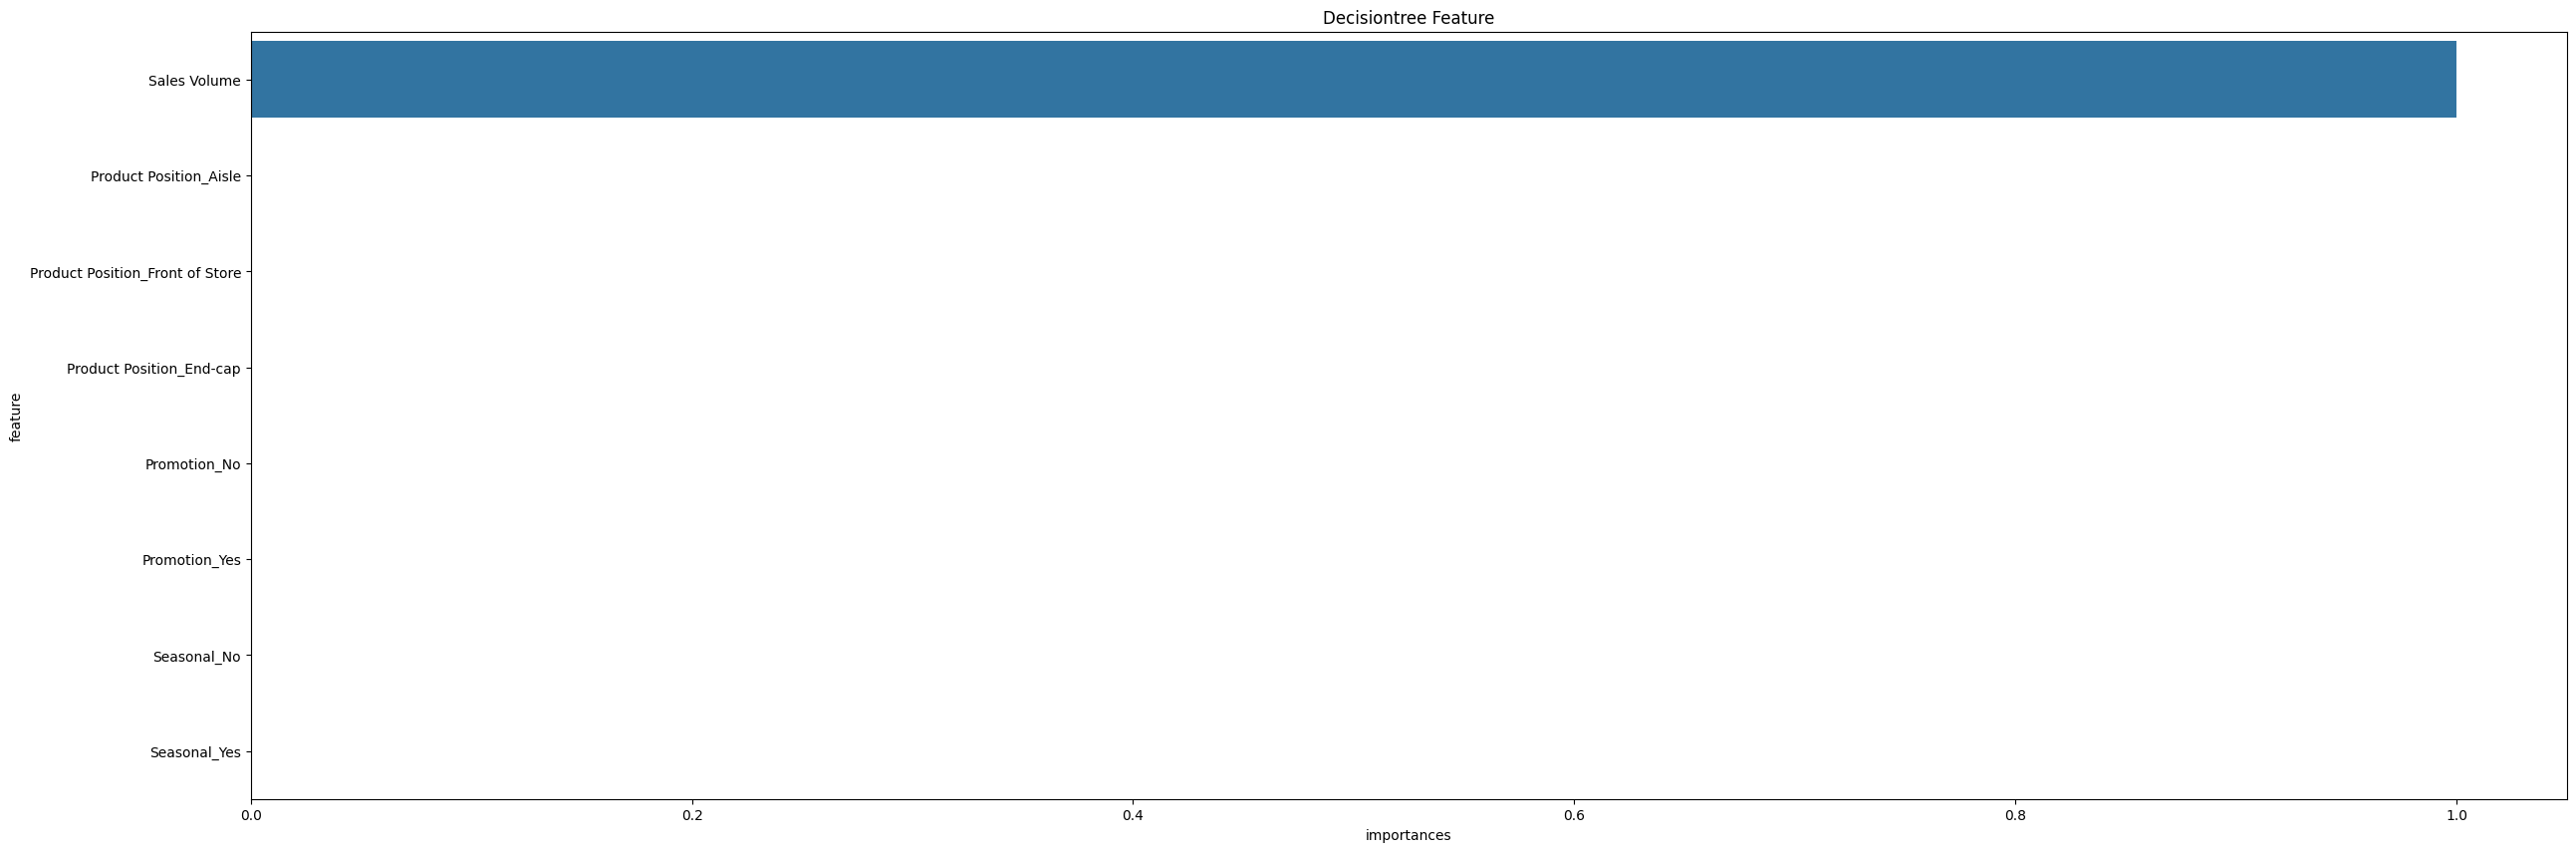

In [468]:
sns.barplot(importance.head(10),x='importances',y='feature',hue='feature')
plt.title('Decisiontree Feature')
plt.show()

In [469]:
from sklearn.ensemble import RandomForestRegressor

In [470]:
params2={'n_estimators':[10,50,100,200,300,500],
         'min_samples_split':[2,5,10],
         'min_samples_leaf':[1,1.1,1.5],
         'max_features':[0.1,0.2,0.5,1],
         'max_depth':[2,3,5,10,20]


}

In [471]:
from sklearn.model_selection import RandomizedSearchCV

In [472]:
random_search=RandomizedSearchCV(RandomForestRegressor(random_state=42),params2).fit(X_train,train_targets)

In [473]:
random_model=random_search.best_estimator_

In [474]:
preds_train2=random_model.predict(X_train)
root_mean_squared_error(preds_train2,train_targets)

50.25554227960771

In [475]:
preds_val2=random_model.predict(X_val)
root_mean_squared_error(preds_val2,val_targets)

57.74791771817454

In [476]:
preds_test2=random_model.predict(X_test)
root_mean_squared_error(preds_test2,test_targets)

47.574570067024105

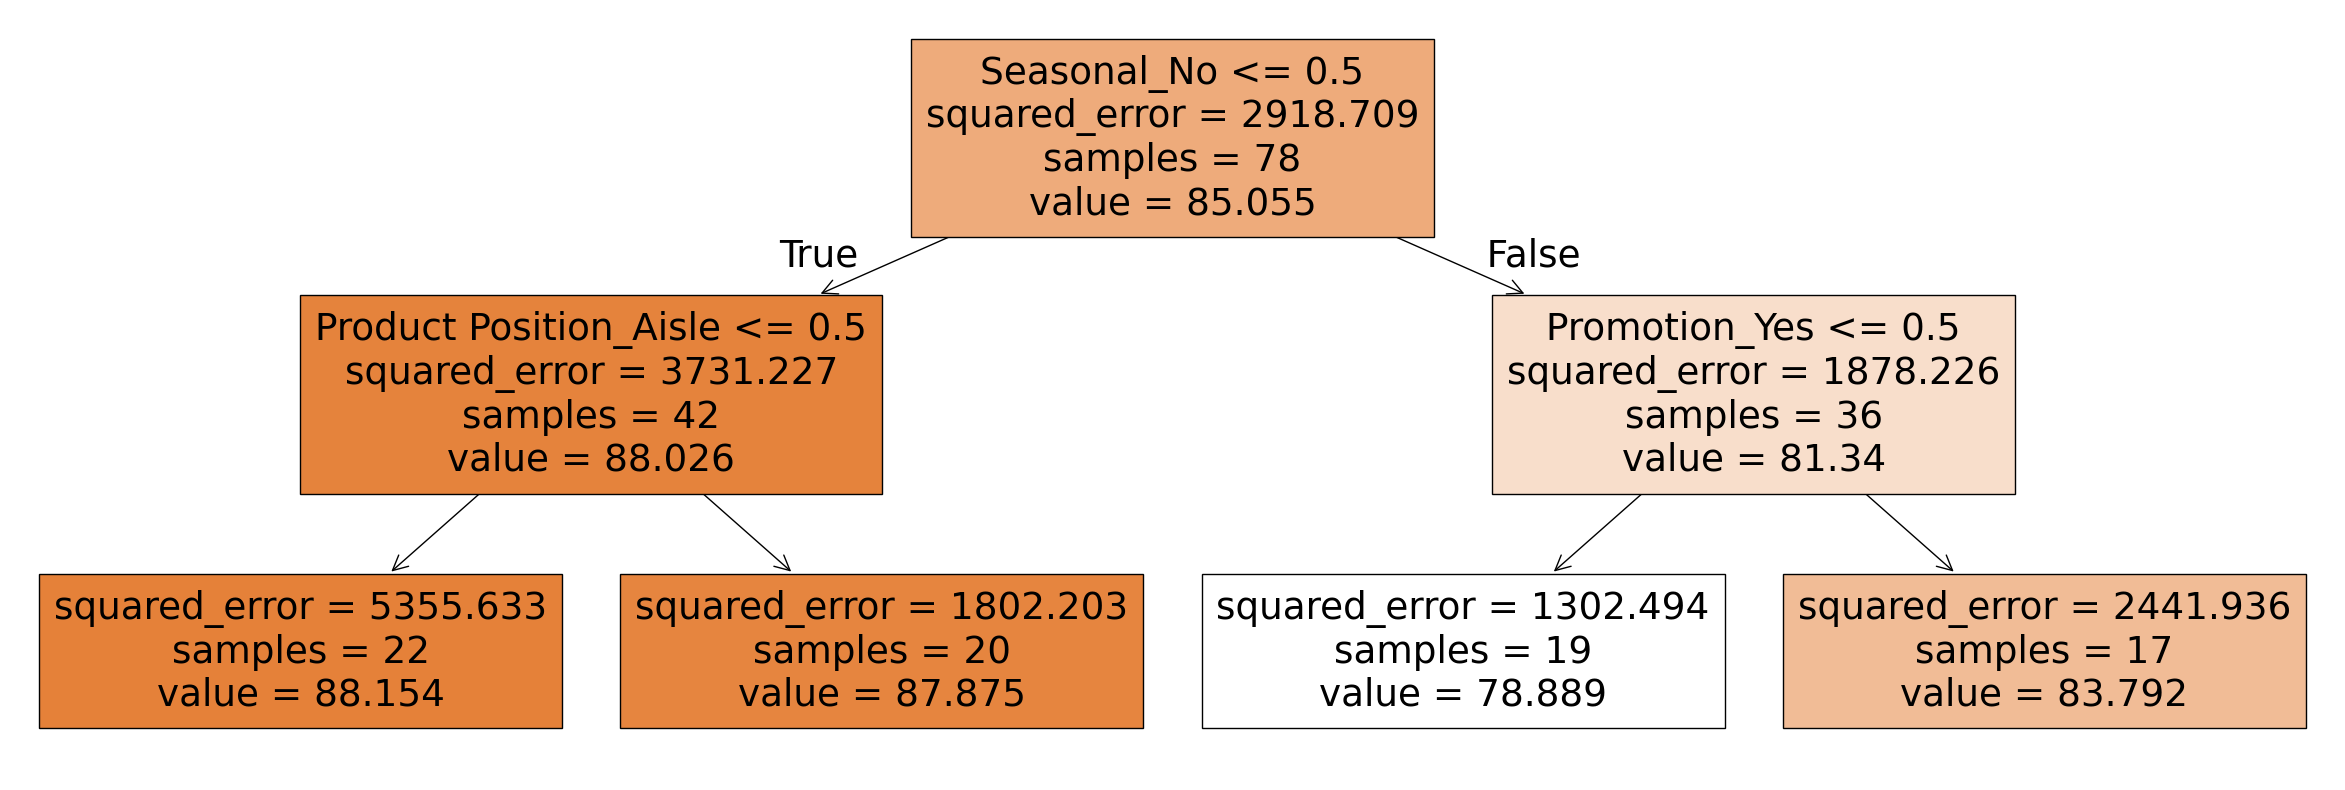

In [477]:
plot_tree(random_model.estimators_[0],feature_names=X_train.columns,filled=True,max_depth=3)
plt.show()

In [478]:
random_importances=pd.DataFrame({
    'feature':X_train.columns,
    'importances':random_model.feature_importances_
}).sort_values('importances',ascending=False)

In [479]:
random_importances.head(10)

,feature,importances
7,Sales Volume,0.304112
2,Product Position_Front of Store,0.126958
5,Seasonal_No,0.119052
6,Seasonal_Yes,0.108195
0,Product Position_Aisle,0.102554
1,Product Position_End-cap,0.087866
4,Promotion_Yes,0.083654
3,Promotion_No,0.067610


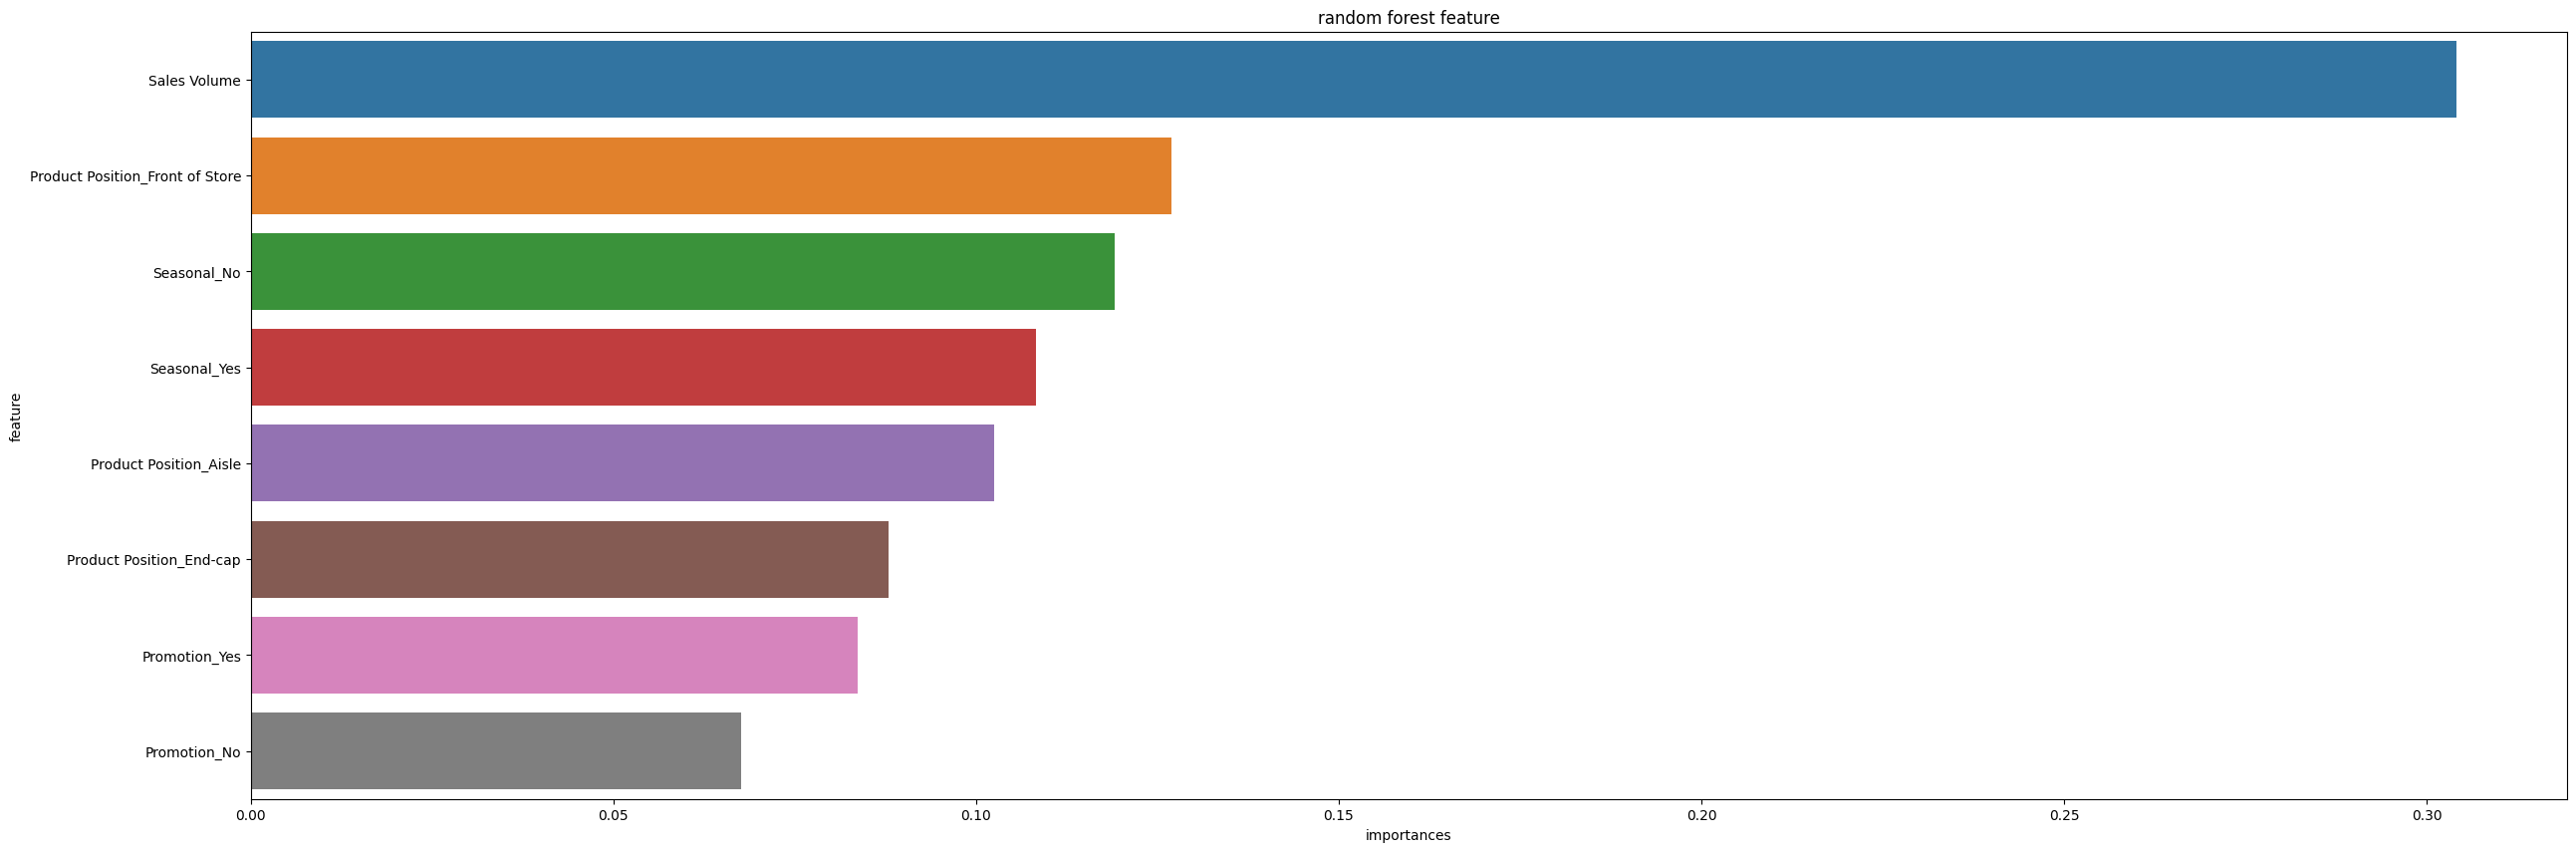

In [480]:
sns.barplot(random_importances.head(10),x='importances',y='feature',hue='feature')
plt.title('random forest feature')
plt.show()

In [481]:
from xgboost import XGBRegressor
from xgboost import plot_tree

In [482]:
params3={'n_estimators':[100,15,200,300,500],
         'max_depth':[2,3,5,6,7,8],
         'learning_rate':[0.1,0.2,0.5,1.1,1.5],
         'n_jobs':[-1,1]

}

In [483]:
r_search=RandomizedSearchCV(XGBRegressor(random_stae=42),params3).fit(X_train,train_targets)

In [484]:
xgb_model=r_search.best_estimator_

In [485]:
preds_train3=xgb_model.predict(X_train)
root_mean_squared_error(preds_train3,train_targets)

44.85857016460729

In [486]:
preds_val3=xgb_model.predict(X_val)
root_mean_squared_error(preds_val3,val_targets)

58.32543250457278

In [487]:
preds_test3=xgb_model.predict(X_test)
root_mean_squared_error(preds_test3,test_targets)

47.859214174963505

In [488]:
def data_train(inputs):
  dg=pd.DataFrame([inputs],index=[0])
  dg[numeric_cols]=imputer.transform(dg[numeric_cols])
  dg[numeric_cols]=scaler.transform(dg[numeric_cols])
  dg[encoded_col]=encoder.transform(dg[categorical_col])
  X=dg[encoded_col + numeric_cols]
  prediction=xgb_model.predict(X)[0]
  return prediction


In [489]:
val_df.head()

,Product ID,Product Position,Promotion,Seasonal,Sales Volume,sku,name,price,currency,Datetime,terms,section,Date,Total_price,time
2,180176,End-cap,Yes,Yes,2220,335342680-800-44,SLIM FIT SUIT JACKET,129.0,USD,2024-02-19 08:50:07.301419,jackets,MAN,2024-02-19,286380,08:50:07.301419
143,163610,Front of Store,Yes,No,2466,311309627-805-39,MOC-TOE SUEDE BOOTS,89.9,USD,2024-02-19 09:00:38.631330,shoes,MAN,2024-02-19,221693,09:00:38.631330
69,182362,Front of Store,No,No,2019,319166635-401-2,CROPPED OVERSHIRT,69.9,USD,2024-02-19 08:50:51.711859,jackets,MAN,2024-02-19,141128,08:50:51.711859
104,110075,Front of Store,Yes,Yes,2185,320771732-800-2,WOOL BLEND FELT TEXTURE JACKET,159.0,USD,2024-02-19 08:51:18.383516,jackets,MAN,2024-02-19,347415,08:51:18.383516
46,138505,Front of Store,No,No,2478,335663355-406-2,RIPPED DENIM JACKET,69.9,USD,2024-02-19 08:50:35.011352,jackets,MAN,2024-02-19,173212,08:50:35.011352


In [490]:
val_df.columns

Index(['Product ID', 'Product Position', 'Promotion', 'Seasonal',
       'Sales Volume', 'sku', 'name', 'price', 'currency', 'Datetime', 'terms',
       'section', 'Date', 'Total_price', 'time'],
      dtype='object')

In [491]:
data={'Product ID': 179801,
  'Product Position': 'Front of Store',
  'Promotion': 'No',
  'Seasonal': 'Yes',
  'Sales Volume': 2608,
  'sku': '311307255-800-2',
  'name': 'CONTRASTING PATCHES BOMBER JACKET',

  'currency': 'USD',
  'Datetime':('2024-02-19 08:50:23.449176'),
  'terms': 'jackets',
  'section': 'MAN',
  'Date':('2024-02-19 00:00:00'),
  'Total_price': 336432,
  'time':(8, 50, 23, 449176)}

In [492]:
inputs

['Product Position', 'Promotion', 'Seasonal', 'Sales Volume']

In [493]:
data_train(data)

np.float32(74.52132)

XGBRegressor has the less loss rate, it is the best for predicting the the prices